# Plantalyze model - Arquitectura 2 v3
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub

 # Hiperparámetros

In [2]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0002
EPOCHS = 50

### Importar dataset

In [3]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

100%|██████████| 1.34G/1.34G [01:21<00:00, 17.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/plants-classification/versions/1


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [4]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar todas las imágenes a 224 x 224
Sin data augmentation para esta iteración del modelo.

Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

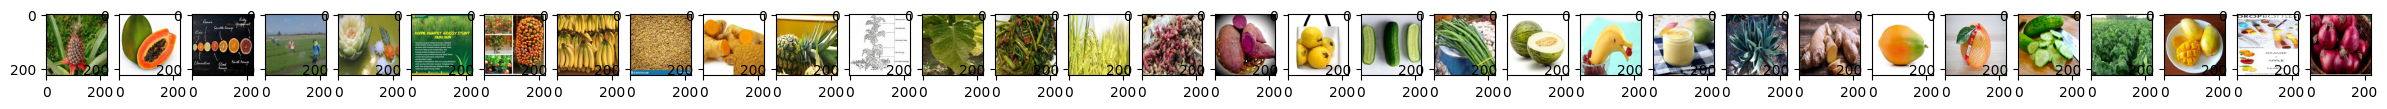

In [5]:
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [8]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Reshape
)

def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

  model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(32, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())

  model.add(Dense(30, activation="softmax"))

  model.compile(optimizer="sgd",
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [9]:
model = get_model_compiled()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │       752,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850,110 (3.24 MB)

 Trainable params: 850,110 (3.24 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Plantalyze

Mounted at /content/drive
/content/drive/MyDrive/Plantalyze


In [11]:
current_directory = "/content/drive/MyDrive/Plantalyze"
checkpoint_path = current_directory + "/checkpoints/checkpoint_arq2_v3.weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_freq= "epoch",
                             save_weights_only = True,
                             verbose = 1)
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [12]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop])

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0564 - loss: 3.3654
Epoch 1: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v3.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v3.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.0834 - loss: 3.2685 - val_accuracy: 0.1537 - val_loss: 2.9805
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1925 - loss: 2.8059
Epoch 2: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v3.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v3.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.2208 - loss: 2.7136 - val_accuracy: 0.2983 - val_loss: 2.4558
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2904 - loss: 2.4617
Epoch 3: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkp

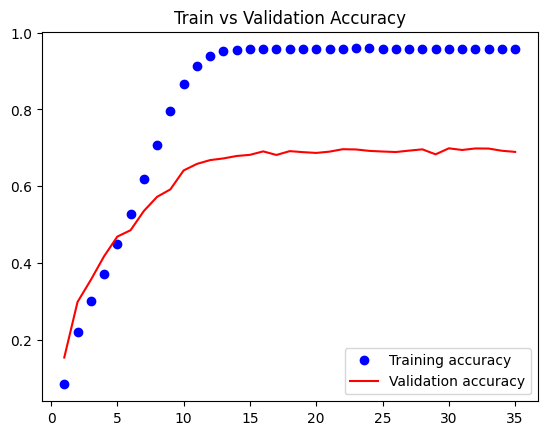

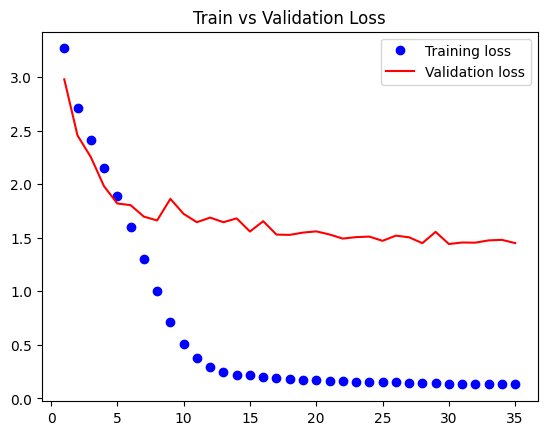

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.plot(epochs_range, acc, "bo", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r", label="Validation accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, "bo", label="Training loss")
plt.plot(epochs_range, val_loss, "r", label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.6423 - loss: 1.7037
Test accuracy: 0.6423333287239075
Test loss: 1.7037322521209717
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step


Classification Report:
               precision    recall  f1-score   support

     aloevera       0.78      0.60      0.68       200
       banana       0.50      0.35      0.42       200
      bilimbi       0.58      0.57      0.58       200
   cantaloupe       0.35      0.30      0.32       200
      cassava       0.69      0.68      0.69       200
      coconut       0.62      0.33      0.43       200
         corn       0.54      0.71      0.62       200
     cucumber       0.72      0.70      0.71       200
      curcuma       0.74      0.80      0.77       200
     eggplant       0.70      0.74      0.72       200
     galangal       0.66      0.88      0.75       200
       ginger       0.47      0.69      0.56       200
        guava       0.65      0.67      0.66       200
         kale       0.82      0.64      0.72       200
    longbeans       0.70      0.83      0.76       200
        mango       0.58      0.42      0.49       200
        melon       0.39      0.35      0

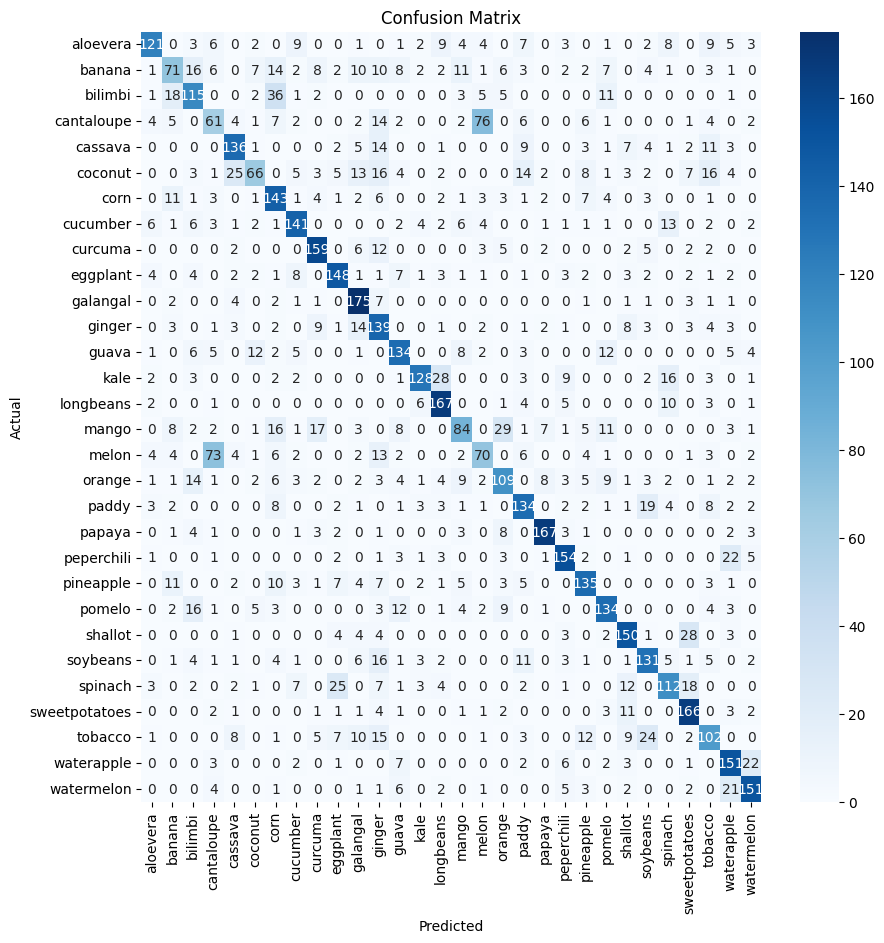

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
